# 05 — Annual rebalance: HRP-CVaR + Black-Litterman tilt

Same 4-ETF universe as notebook 04 (SWDA.L, XLK, IAU, BIL), but with:
- **Hierarchical Risk Parity** (Riskfolio-Lib `HCPortfolio`) using **CVaR** as the risk measure
- **Black-Litterman** posterior (Riskfolio `Portfolio.blacklitterman_stats`) to tilt toward a prior view
- **Annual rebalance** on the first trading day of each calendar year, using a 3-year lookback

### Why we pin BIL at 25%

BIL is ultra-short T-bills — daily vol ~0.01% — so pure HRP-CVaR dumps ≥94% into it (all the others look "risky" relative to cash). That collapses the portfolio to a cash account. We **pin BIL at 25%** (the user's category-slot design) and let HRP-CVaR allocate the remaining 75% across the 3 risky ETFs. The notebook also shows the pure-HRP variant for comparison.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Setup

In [2]:
INIT_CASH = 10_000.0
SIM_START = "2016-01-31"
SIM_END = "2026-01-31"
LOOKBACK_DAYS = 756       # ~3 trading years
CASH_PIN = {"BIL": 0.25}

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()
BENCHMARK = "SPY"

# Pull enough history for the 3y lookback before SIM_START
prices = mf.get_prices(SYMBOLS + [BENCHMARK], start="2013-01-01", end=SIM_END)
rebalance_dates = mf.annual_rebalance_dates(prices, start=SIM_START)
print(f"rebalance dates ({len(rebalance_dates)}):")
print([d.date().isoformat() for d in rebalance_dates])

rebalance dates (11):
['2016-02-01', '2017-01-03', '2018-01-02', '2019-01-02', '2020-01-02', '2021-01-04', '2022-01-03', '2023-01-03', '2024-01-02', '2025-01-02', '2026-01-02']


## 2. Define strategies

All three weight functions take a window of historical daily returns and return target weights summing to 1.

In [3]:
# BL view: SWDA.L (world equity) outperforms BIL (cash) by 5% annualized.
#   P has one row per view, one column per asset (same order as returns/prices)
#   Q gives the expected excess return of the view at the returns frequency (daily)
VIEW_P = pd.DataFrame([[1, 0, 0, -1]], columns=SYMBOLS)
VIEW_Q = pd.DataFrame([[0.05 / 252]])  # 5% per year → per trading day
BL_TILT = 0.30  # 30% blend toward BL-MV weights, 70% HRP


def strat_hrp_pure(rets):
    return mf.hrp_cvar_weights(rets)


def strat_hrp_pinned(rets):
    return mf.hrp_cvar_weights_with_fixed(rets, fixed_weights=CASH_PIN)


def strat_hrp_pinned_bl(rets):
    w_hrp = mf.hrp_cvar_weights_with_fixed(rets, fixed_weights=CASH_PIN)
    w_bl = mf.bl_mv_weights(rets, prior_weights=w_hrp, P=VIEW_P, Q=VIEW_Q, obj="Utility")
    w = (1.0 - BL_TILT) * w_hrp + BL_TILT * w_bl
    return w / w.sum()

## 3. Build target-weight schedules

In [4]:
targets = {
    "A pure HRP-CVaR":      mf.build_target_weights(prices[SYMBOLS], strat_hrp_pure,       rebalance_dates, LOOKBACK_DAYS),
    "B pinned HRP-CVaR":    mf.build_target_weights(prices[SYMBOLS], strat_hrp_pinned,     rebalance_dates, LOOKBACK_DAYS),
    "C pinned HRP + BL":    mf.build_target_weights(prices[SYMBOLS], strat_hrp_pinned_bl,  rebalance_dates, LOOKBACK_DAYS),
}

weights_view = pd.concat(
    {name: t.loc[rebalance_dates].round(3) for name, t in targets.items()}, axis=0, names=["strategy", "rebalance"]
)
weights_view

symbol                        SWDA.L    XLK    IAU    BIL
strategy          rebalance                              
A pure HRP-CVaR   2016-02-01   0.012  0.011  0.010  0.967
                  2017-01-03   0.014  0.012  0.015  0.960
                  2018-01-02   0.018  0.015  0.021  0.946
                  2019-01-02   0.030  0.021  0.040  0.909
                  2020-01-02   0.040  0.026  0.070  0.864
                  2021-01-04   0.028  0.018  0.046  0.909
                  2022-01-03   0.022  0.014  0.029  0.936
                  2023-01-03   0.020  0.012  0.023  0.945
                  2024-01-02   0.071  0.041  0.071  0.817
                  2025-01-02   0.107  0.051  0.088  0.754
                  2026-01-02   0.126  0.063  0.092  0.719
B pinned HRP-CVaR 2016-02-01   0.231  0.215  0.304  0.250
                  2017-01-03   0.220  0.184  0.346  0.250
                  2018-01-02   0.209  0.173  0.368  0.250
                  2019-01-02   0.207  0.144  0.399  0.250
                  2020-01-02   0.183  0.123  0.444  0.250
                  2021-01-04   0.189  0.119  0.441  0.250
                  2022-01-03   0.208  0.130  0.412  0.250
                  2023-01-03   0.205  0.124  0.422  0.250
                  2024-01-02   0.227  0.132  0.390  0.250
                  2025-01-02   0.234  0.126  0.390  0.250
                  2026-01-02   0.255  0.145  0.350  0.250
C pinned HRP + BL 2016-02-01   0.274  0.182  0.257  0.287
                  2017-01-03   0.216  0.206  0.403  0.175
                  2018-01-02   0.169  0.197  0.459  0.175
                  2019-01-02   0.165  0.176  0.483  0.175
                  2020-01-02   0.128  0.173  0.524  0.175
                  2021-01-04   0.133  0.184  0.508  0.175
                  2022-01-03   0.146  0.207  0.472  0.175
                  2023-01-03   0.197  0.149  0.479  0.175
                  2024-01-02   0.159  0.220  0.446  0.175
                  2025-01-02   0.164  0.222  0.439  0.175
                  2026-01-02   0.178  0.245  0.402  0.175

## 4. Run simulations

In [5]:
pfs = {name: mf.run_rebalance_sim(prices[SYMBOLS], t, init_cash=INIT_CASH) for name, t in targets.items()}

# Baselines
pfs["EW B&H (nb 04)"] = mf.buy_and_hold(prices[SYMBOLS], dict(zip(SYMBOLS, [0.25] * 4)), init_cash=INIT_CASH)
pfs[f"{BENCHMARK} B&H"] = mf.single_asset_buy_and_hold(prices[BENCHMARK], init_cash=INIT_CASH)


def row(pf):
    return {
        "total_return":          float(pf.total_return()),
        "annualized_return":     float(pf.annualized_return()),
        "annualized_volatility": float(pf.annualized_volatility()),
        "sharpe_ratio":          float(pf.sharpe_ratio()),
        "sortino_ratio":         float(pf.sortino_ratio()),
        "calmar_ratio":          float(pf.calmar_ratio()),
        "max_drawdown":          float(pf.max_drawdown()),
    }


stats = pd.DataFrame({name: row(pf) for name, pf in pfs.items()}).round(4)
stats

,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
total_return,0.1524,2.2405,2.6228,3.6007,3.7376
annualized_return,0.0162,0.1421,0.1566,0.1882,0.1884
annualized_volatility,0.0155,0.0877,0.1004,0.1533,0.2040
sharpe_ratio,1.0432,1.5598,1.4988,1.2019,0.9483
sortino_ratio,1.3772,2.2702,2.1848,1.7020,1.3306
calmar_ratio,0.4997,1.1972,1.0983,0.8427,0.5523
max_drawdown,-0.0323,-0.1187,-0.1426,-0.2234,-0.3410


## 5. Equity curves & drawdowns

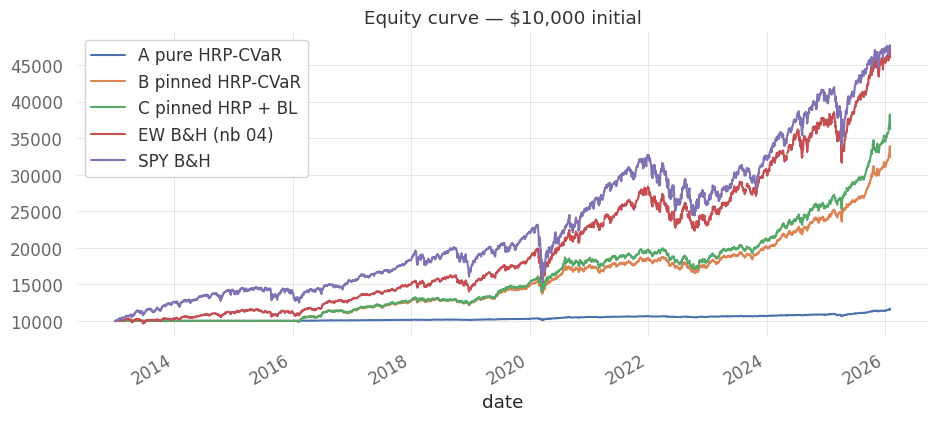

In [6]:
equity = pd.DataFrame({name: pf.value() for name, pf in pfs.items()})
equity.plot(figsize=(11, 4.5), title=f"Equity curve — ${INIT_CASH:,.0f} initial", grid=True);

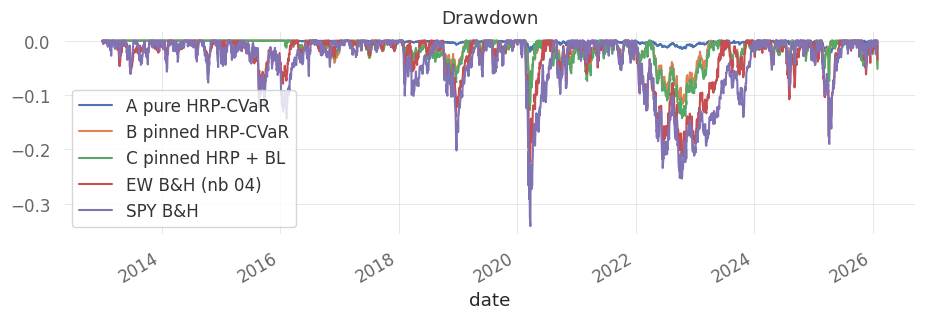

In [7]:
dd = pd.DataFrame({name: pf.drawdown() for name, pf in pfs.items()})
dd.plot(figsize=(11, 3), title="Drawdown", grid=True);

### Tear sheet — standardized metrics

One standardized row set (matching `scripts/build_tear_sheet.py`) for all five equity lines, in **two annualization bases — we keep both**:

- **`Annualized (2016–2026, ~10y)`** — the figures to cite. Every line is sliced to the common investment window and CAGR is taken over *elapsed calendar years*, with volatility / Sharpe / Sortino at `√252` and downstream annualized quantities (tracking error, idio vol, α) on the same basis. Written to `reports/nb05_tear_sheet_annualized.csv`.
- **`vectorbt (native)`** — what the stats table above reports: vectorbt's own output over the **full simulated series**, using a 365-day period basis. Kept for continuity. Written to `reports/nb05_tear_sheet_vbt.csv`.

**Why they differ — two effects, both in the vectorbt column:**

1. **The 2013→2016 flat is the HRP-CVaR lookback burn-in, not performance.** CVaR is the mean of the worst 5% of a trailing `LOOKBACK_DAYS = 756` (~3y) window, so the first investable weight can't exist until three years of history have accrued; the book sits in cash until the first 2016 rebalance. vectorbt annualizes over *all* rows including that flat, spreading the return over the wrong number of years. The annualized sheet evaluates only the post-burn-in window (2016-02-01 → 2026-01-30, ≈10.0y) — standard backtest practice: never count the estimation window as return.
2. **vectorbt applies a 365-day year to trading-day-sampled returns.** Returns only occur on ~252 trading days, so scaling daily vol by `√365` over-states annualized volatility and Sharpe by `√(365/252) ≈ 1.20`. The annualized sheet uses `√252`.

Net for **B pinned HRP-CVaR**: CAGR **12.5%** (annualized) vs 14.2% (vbt); Sharpe **1.48** vs 1.56. The convention-independent rows (Total Return, Max Drawdown, VaR/CVaR, skew, kurtosis, SSR, HAC, β, correlation) also differ between the two columns because the vbt column still carries the 3y flat — e.g. the burn-in zeros drag its hit rate down and inflate its kurtosis; the annualized column's kurtosis (7.2 for B) matches the return-distribution section.

The three metric blocks — **risk/return + tails**, **skill (SSR / HAC t)**, and **benchmark-relative + Paleologo CAPM** — are as documented in the earlier tear-sheet notes; `SSR` and the Newey-West `HAC t` reuse the repo's `macro_framework.ssr` canon.

In [8]:
import numpy as np
from macro_framework.ssr import compute_ssr, newey_west_var

TRADING_DAYS = 252


def _capm(y, x):
    """OLS y = a + b·x; returns alpha_daily, beta, R², residuals."""
    X = np.column_stack([np.ones(len(x)), x.to_numpy()])
    coef, *_ = np.linalg.lstsq(X, y.to_numpy(), rcond=None)
    resid = y.to_numpy() - X @ coef
    ss_res, ss_tot = float((resid**2).sum()), float(((y - y.mean())**2).sum())
    return coef[0], coef[1], (1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan), pd.Series(resid, index=y.index)


def _metrics(r, val, bench_r, ppy, cagr, maxdd):
    """All standardized rows from a daily-return series r, equity val, benchmark bench_r,
    given a periods-per-year `ppy`, a precomputed `cagr` and `maxdd`."""
    dsd = np.sqrt((np.minimum(r, 0.0) ** 2).mean())
    var5 = r.quantile(0.05)
    ssr = compute_ssr(r)
    lr_var, L = newey_west_var(r.to_numpy())
    hac_t = r.mean() / np.sqrt(lr_var / len(r)) if lr_var > 0 else np.nan
    b = bench_r.reindex(r.index).dropna(); rr = r.reindex(b.index); active = rr - b
    te = active.std(ddof=1) * np.sqrt(ppy)
    a_d, beta, r2, resid = _capm(rr, b)
    idio = resid.std(ddof=1) * np.sqrt(ppy)
    alpha, ar = a_d * ppy, active.mean() * ppy
    return {
        "Total Return": float(val.iloc[-1] / val.iloc[0] - 1), "CAGR": float(cagr),
        "Ann. Volatility": float(r.std(ddof=1) * np.sqrt(ppy)),
        "Sharpe": float(r.mean() / r.std(ddof=1) * np.sqrt(ppy)),
        "Downside vol (daily)": float(dsd),
        "Sortino": float(r.mean() / dsd * np.sqrt(ppy)) if dsd > 0 else np.nan,
        "Max Drawdown": float(maxdd), "Calmar": float(cagr / abs(maxdd)) if maxdd else np.nan,
        "VaR 95 (daily)": float(var5), "CVaR 95 (daily)": float(r[r <= var5].mean()),
        "Skew": float(r.skew()), "Excess Kurtosis": float(r.kurtosis()),
        "Hit Rate": float((r > 0).mean()), "SSR (Sharpe Stability)": float(ssr.ssr),
        "HAC t (mean, NW)": float(hac_t), "HAC lag L": int(L),
        "Correlation to S&P 500": float(rr.corr(b)), "Beta": float(beta),
        "Active Return (ann.)": float(ar), "Tracking Error (ann.)": float(te),
        "Information Ratio": float(ar / te) if te > 1e-6 else np.nan, "R2 (CAPM, 1 factor)": float(r2),
        "Idio vol sigma_e (ann.)": float(idio), "alpha (Regression, ann.)": float(alpha),
        "Appraisal Ratio (a/se)": float(alpha / idio) if idio > 1e-4 else np.nan,
    }


def tear_sheet(pfs, start, end, bench_name="SPY B&H"):
    """Annualized (cite-me) sheet: every line sliced to the common [start, end] investment
    window (post HRP-CVaR lookback burn-in); CAGR over elapsed calendar years, sqrt(252)."""
    bench_r = pfs[bench_name].returns().loc[start:end]
    out = {}
    for name, pf in pfs.items():
        val = pf.value().loc[start:end]
        r = pf.returns().loc[start:end].dropna()
        yrs = (val.index[-1] - val.index[0]).days / 365.25
        cagr = (val.iloc[-1] / val.iloc[0]) ** (1 / yrs) - 1
        maxdd = float((val / val.cummax() - 1).min())
        out[name] = _metrics(r, val, bench_r, TRADING_DAYS, cagr, maxdd)
    return pd.DataFrame(out)


def tear_sheet_vbt(pfs, bench_name="SPY B&H"):
    """Reference sheet: vectorbt's native output over the FULL simulated series (365-day
    period basis, includes the 3y lookback burn-in). Matches the stats table above."""
    bench_r = pfs[bench_name].returns()
    out = {}
    for name, pf in pfs.items():
        r = pf.returns().dropna()
        ppy = (float(pf.annualized_volatility()) / r.std(ddof=1)) ** 2  # ~365
        m = _metrics(r, pf.value(), bench_r, ppy, float(pf.annualized_return()), float(pf.max_drawdown()))
        m.update({"Ann. Volatility": float(pf.annualized_volatility()), "Sharpe": float(pf.sharpe_ratio()),
                  "Sortino": float(pf.sortino_ratio()), "Calmar": float(pf.calmar_ratio())})
        out[name] = m
    return pd.DataFrame(out)


_PCT = {"Total Return", "CAGR", "Ann. Volatility", "Downside vol (daily)", "Max Drawdown",
        "VaR 95 (daily)", "CVaR 95 (daily)", "Hit Rate", "Active Return (ann.)",
        "Tracking Error (ann.)", "Idio vol sigma_e (ann.)", "alpha (Regression, ann.)"}


def fmt(sheet):
    def cell(m, v):
        if m == "HAC lag L":
            return f"{int(v)}"
        return f"{v*100:.1f}%" if m in _PCT else f"{v:.2f}"
    return pd.DataFrame({c: [cell(m, sheet.loc[m, c]) for m in sheet.index]
                         for c in sheet.columns}, index=sheet.index)


sheet_ann = tear_sheet(pfs, SIM_START, SIM_END)
sheet_vbt = tear_sheet_vbt(pfs)
reports = Path.cwd().parent / "reports"
reports.mkdir(exist_ok=True)
sheet_ann.to_csv(reports / "nb05_tear_sheet_annualized.csv", float_format="%.6f")
sheet_vbt.to_csv(reports / "nb05_tear_sheet_vbt.csv", float_format="%.6f")
print(f"wrote {reports/'nb05_tear_sheet_annualized.csv'}\n      {reports/'nb05_tear_sheet_vbt.csv'}")

print("\n=== Annualized (2016–2026, ~10y calendar, √252) — cite these ===")
display(fmt(sheet_ann))
print("=== vectorbt (native, full simulated series, 365-day basis) — reference ===")
display(fmt(sheet_vbt))

wrote /home/mc/projects/Global_Macro_AI_Factors/reports/nb05_tear_sheet_annualized.csv
      /home/mc/projects/Global_Macro_AI_Factors/reports/nb05_tear_sheet_vbt.csv

=== Annualized (2016–2026, ~10y calendar, √252) — cite these ===


,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
Total Return,15.2%,224.1%,262.3%,315.8%,257.3%
CAGR,1.4%,12.5%,13.7%,15.3%,13.6%
Ann. Volatility,1.5%,8.3%,9.5%,13.9%,18.0%
Sharpe,0.99,1.48,1.43,1.12,0.80
Downside vol (daily),0.1%,0.4%,0.4%,0.6%,0.8%
Sortino,1.31,2.16,2.08,1.59,1.12
Max Drawdown,-3.2%,-11.9%,-14.3%,-22.3%,-34.1%
Calmar,0.44,1.05,0.96,0.69,0.40
VaR 95 (daily),-0.1%,-0.8%,-0.9%,-1.4%,-1.7%
CVaR 95 (daily),-0.2%,-1.2%,-1.4%,-2.1%,-2.8%


=== vectorbt (native, full simulated series, 365-day basis) — reference ===


,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
Total Return,15.2%,224.1%,262.3%,360.1%,373.8%
CAGR,1.6%,14.2%,15.7%,18.8%,18.8%
Ann. Volatility,1.5%,8.8%,10.0%,15.3%,20.4%
Sharpe,1.04,1.56,1.50,1.20,0.95
Downside vol (daily),0.1%,0.3%,0.4%,0.6%,0.8%
Sortino,1.38,2.27,2.18,1.70,1.33
Max Drawdown,-3.2%,-11.9%,-14.3%,-22.3%,-34.1%
Calmar,0.50,1.20,1.10,0.84,0.55
VaR 95 (daily),-0.1%,-0.7%,-0.8%,-1.2%,-1.6%
CVaR 95 (daily),-0.2%,-1.1%,-1.3%,-1.9%,-2.6%


### Attribution — market factor vs idiosyncratic (Paleologo)

The tear sheet reports α, β and R² but doesn't *split the return* into what the market gave you (β·market) and what it didn't (α). Paleologo's point is that this split, done at **two levels**, is what turns "risk reduction, not alpha" from a claim into a number. Both regressions use HAC (Newey-West, `maxlags=5`) standard errors on daily returns over 2016–2026.

**Level 1 — single-factor CAPM (market = SPY).** `r_p = α + β·r_SPY + ε`. The identity `E[r_p] = α + β·E[r_SPY]` splits each line's annualized return exactly into a **market component** (β·market) and an **alpha-to-SPY** component (the stacked bar below).

**Level 2 — own 4-ETF basket** (`SWDA.L, XLK, IAU, BIL`). Regress the same return on its *own* asset-class factors. This is the check that keeps Level 1 honest: for a 4-asset book, a large single-factor α can be real skill **or** just exposure to factors SPY can't see (gold, duration, cash carry). The basket R² tells you which.

**What the numbers say (and how they refine the earlier conclusion):**

- HRP runs a **low market beta** — 0.27 (B), 0.33 (C) vs SPY's 1.0 — so only ~3.7–4.4pp of a ~12–14% return is market-driven. That low loading is where the shallow drawdowns come from, exactly as expected.
- The **single-factor α is large and HAC-significant** (8.7%/yr, t ≈ 4.2 for B) — so the naive read "no alpha" is *wrong at Level 1*. But the **4-ETF basket R² ≈ 0.98** (idiosyncratic residual only ~1.2%) shows that α is **not timing skill**: 98% of the return is spanned by static exposure to the book's own sleeves. The "alpha to SPY" is gold + cash-carry premia invisible to a market-only model.
- So the precise statement is: **allocation-timing alpha ≈ 0** (basket residual near zero), and the edge over SPY is **factor design — lower market beta plus diversification into non-equity premia — not skill.** The IR ≈ 0 from the tear sheet is the dollar-for-dollar shadow of the same fact: at β = 1 (what IR implicitly assumes) HRP doesn't beat SPY; its advantage only appears once you credit it for taking less market risk.

Sanity anchor: SPY's *own-basket* R² is only 0.87 (residual 6.5%, the largest of any line) — because SPY is the one series **not** built from these four ETFs. The basket regression is doing real work, not fitting noise.

,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
"Total (ann, arith)",1.5%,12.4%,13.6%,15.5%,14.4%
Market β·mkt (ann),0.6%,3.7%,4.4%,9.3%,14.4%
Alpha vs SPY (ann),0.8%,8.7%,9.2%,6.3%,0.0%
Beta (mkt),0.05,0.27,0.33,0.69,1.00
t(alpha) HAC,2.21,4.21,3.97,3.23,2.19
R2 market (1-factor),0.33,0.35,0.38,0.79,1.00
Idio vol vs mkt (ann),1.2%,6.7%,7.5%,6.4%,0.0%
R2 own 4-ETF basket,0.81,0.98,0.97,0.99,0.87
Idio vol vs basket (ann),0.6%,1.2%,1.6%,1.4%,6.5%


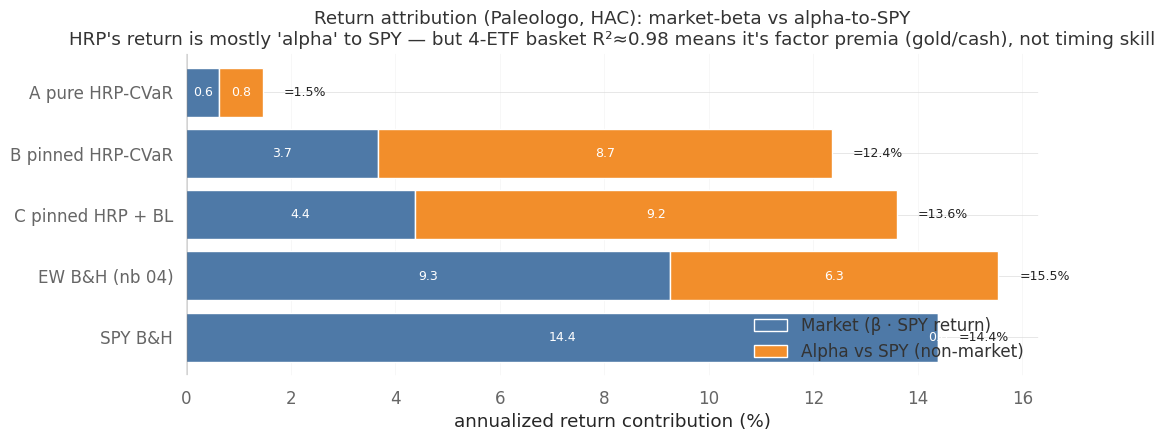

In [9]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

A, MAXLAGS = 252, 5
mkt = pfs["SPY B&H"].returns().loc[SIM_START:SIM_END].rename("mkt")     # SPY daily
basket = prices[SYMBOLS].pct_change().loc[SIM_START:SIM_END]            # own 4-ETF factors

attr = {}
for name, pf in pfs.items():
    r = pf.returns().loc[SIM_START:SIM_END].dropna().rename("y")
    d = pd.concat([r, mkt], axis=1).dropna()                            # align LSE/US holidays
    res = sm.OLS(d["y"], sm.add_constant(d["mkt"])).fit(cov_type="HAC", cov_kwds={"maxlags": MAXLAGS})
    beta = res.params.iloc[1]
    alpha_ann = res.params.iloc[0] * A
    mkt_ann = d["mkt"].mean() * A
    db = pd.concat([r, basket], axis=1).dropna()
    resb = sm.OLS(db["y"], sm.add_constant(db[SYMBOLS])).fit(cov_type="HAC", cov_kwds={"maxlags": MAXLAGS})
    attr[name] = {
        "Total (ann, arith)":       float(d["y"].mean() * A),
        "Market β·mkt (ann)":       float(beta * mkt_ann),
        "Alpha vs SPY (ann)":       float(alpha_ann),
        "Beta (mkt)":               float(beta),
        "t(alpha) HAC":             float(res.tvalues.iloc[0]),
        "R2 market (1-factor)":     float(res.rsquared),
        "Idio vol vs mkt (ann)":    float(res.resid.std(ddof=1) * np.sqrt(A)),
        "R2 own 4-ETF basket":      float(resb.rsquared),
        "Idio vol vs basket (ann)": float(resb.resid.std(ddof=1) * np.sqrt(A)),
    }
attr = pd.DataFrame(attr)

_APCT = {"Total (ann, arith)", "Market β·mkt (ann)", "Alpha vs SPY (ann)",
         "Idio vol vs mkt (ann)", "Idio vol vs basket (ann)"}
display(pd.DataFrame({c: [f"{attr.loc[m, c]*100:.1f}%" if m in _APCT else f"{attr.loc[m, c]:.2f}"
                         for m in attr.index] for c in attr.columns}, index=attr.index))

# stacked decomposition: market (β·mkt) + alpha-to-SPY = total return, per line
names = list(attr.columns)
mktc = attr.loc["Market β·mkt (ann)"].values * 100
alpc = attr.loc["Alpha vs SPY (ann)"].values * 100
y = np.arange(len(names))[::-1]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.barh(y, mktc, color="#4e79a7", label="Market (β · SPY return)")
ax.barh(y, alpc, left=mktc, color="#f28e2b", label="Alpha vs SPY (non-market)")
for yi, m, a in zip(y, mktc, alpc):
    ax.text(m / 2, yi, f"{m:.1f}", ha="center", va="center", color="white", fontsize=9)
    ax.text(m + a / 2, yi, f"{a:.1f}", ha="center", va="center", color="white", fontsize=9)
    ax.text(m + a + 0.4, yi, f"={m + a:.1f}%", va="center", fontsize=9, color="#222")
ax.set_yticks(y); ax.set_yticklabels(names)
ax.set_xlabel("annualized return contribution (%)")
ax.set_title("Return attribution (Paleologo, HAC): market-beta vs alpha-to-SPY\n"
             "HRP's return is mostly 'alpha' to SPY — but 4-ETF basket R²≈0.98 means it's factor "
             "premia (gold/cash), not timing skill")
ax.axvline(0, color="#222", lw=1); ax.grid(True, axis="x", alpha=0.3)
ax.legend(frameon=False, loc="lower right");

## 5.1 What actually tilts the Black-Litterman weights?

Strategy C is `0.7 · w_HRP + 0.3 · w_BL`. It's tempting to read the tilt as "our view (world equity beats cash by 5%/yr) pushes us into SWDA.L." The numbers say the opposite. Three forces move `w_BL` off the HRP prior, and the hand-set view is the **weakest and backwards** of them.

**1. The reverse-optimized equilibrium prior (`eq=True`) does most of the work.** `blacklitterman_stats` doesn't use historical means as the prior — it back-solves implied returns `Π = δ · Σ · w_HRP` from the HRP weights and the Ledoit-Wolf covariance. High-vol, high-recent-drift sleeves (XLK, IAU) get large implied returns; BIL gets ~0. That prior, not the view, sets the direction.

**2. The mean-variance *utility* optimizer concentrates.** `obj="Utility"` on `(μ_BL, Σ_BL)` is a corner-seeking optimizer, not risk parity. It repeatedly drives SWDA.L and BIL to **exactly 0** and piles the book into XLK + IAU (see the final-rebalance row: `w_bl = [0.00, 0.52, 0.48, 0.00]`). This is the single biggest weight mover — and it is a *property of the optimizer*, present even before any view.

**3. The view is contractionary, not expansionary.** At the last rebalance the equilibrium prior already implies an **18.3%/yr** SWDA.L−BIL premium; the view asserts only **5%/yr**. Blender that it is, BL pulls the posterior premium *down* toward the view — so `μ_BL` for SWDA.L (10.2%) sits *below* its equilibrium `Π` (18.7%), and the view ends up **trimming** world equity. A view meant as "bullish equity" acts as a brake, because it under-states what the equilibrium already assumes.

**The 0.30 blend is the real risk control.** Pooled over 11 rebalances the raw BL tilt is large — mean Δw ≈ SWDA.L −0.13, XLK +0.18, IAU +0.18, BIL −0.22 — but only 30% of it reaches the portfolio, and HRP's 70% keeps BIL near its pinned 0.175 (`0.7·0.25`) even when BL zeroes it. Without that blend, "HRP + BL" would just be an unconstrained MV bet on tech and gold.

The histogram below pools all 44 tilts (4 assets × 11 rebalances): a clean bimodal split — cash and world equity pushed down, tech and gold pushed up — with essentially nothing near zero. BL here is not nudging; it is reshuffling, and the blend is what keeps that reshuffle survivable.

BL decomposition at final rebalance 2026-01-02:


,SWDA.L,XLK,IAU,BIL
Pi_ann,0.1871,0.3850,0.2616,0.004
muBL_ann,0.1024,0.3584,0.2872,0.000
w_hrp,0.2521,0.1419,0.3560,0.250
w_bl,0.0000,0.5170,0.4830,0.000
w_C,0.1765,0.2544,0.3941,0.175


SWDA.L-BIL premium: equilibrium implies +18.3%/yr, the view asserts +5.0%/yr
-> the view is CONTRACTIONARY: it caps a premium equilibrium already exceeds, so it trims SWDA.L instead of adding to it.

BL weight tilt  Δw = w_bl - w_hrp  across 11 rebalances:


,SWDA.L,XLK,IAU,BIL
mean,-0.134,0.179,0.179,-0.224
std,0.124,0.130,0.108,0.086
min,-0.252,-0.081,-0.114,-0.250
max,0.159,0.375,0.292,0.035


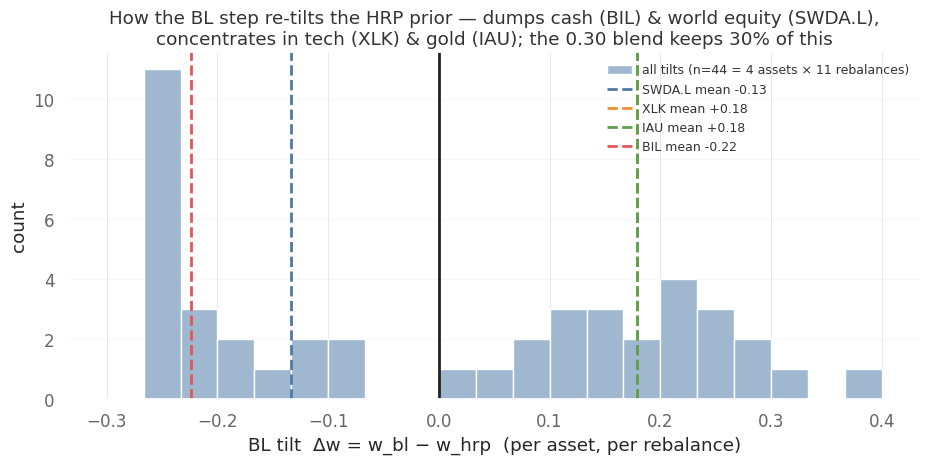

In [10]:
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import riskfolio as rp

# Reconstruct the BL internals that strat_hrp_pinned_bl hides, so we can see the
# equilibrium prior (Pi) and posterior (mu_bl), not just the final weights.
ASSET_COLOR = {"SWDA.L": "#4e79a7", "XLK": "#f28e2b", "IAU": "#59a14f", "BIL": "#e15759"}
rets_full = prices[SYMBOLS].pct_change()


def bl_internals(win, w_prior):
    """Mirror of mf.bl_mv_weights, but also returns Pi (equilibrium) and mu_bl (posterior)."""
    with contextlib.redirect_stdout(io.StringIO()):
        port = rp.Portfolio(returns=win)
        port.assets_stats(method_mu="hist", method_cov="ledoit")
        port.blacklitterman_stats(P=VIEW_P, Q=VIEW_Q, rf=0.0,
                                  w=w_prior.to_frame(), delta=None, eq=True)
        w_bl = port.optimization(model="BL", rm="MV", obj="Utility", rf=0.0, hist=False)
    ser = lambda x: pd.Series(np.ravel(np.asarray(x)), index=SYMBOLS)
    return ser(port.mu) * 252, ser(port.mu_bl) * 252, ser(w_bl["weights"].reindex(SYMBOLS).fillna(0))


tilts, last = {}, {}
for d in rebalance_dates:
    win = rets_full.loc[:d].dropna().iloc[-LOOKBACK_DAYS:]
    w_hrp = mf.hrp_cvar_weights_with_fixed(win, fixed_weights=CASH_PIN)[SYMBOLS]
    pi, mu_bl, w_bl = bl_internals(win, w_hrp)
    tilts[d.date()] = w_bl - w_hrp
    if d == rebalance_dates[-1]:
        w_c = 0.7 * w_hrp + 0.3 * w_bl
        last = {"Pi_ann": pi, "muBL_ann": mu_bl, "w_hrp": w_hrp, "w_bl": w_bl, "w_C": w_c / w_c.sum()}

print(f"BL decomposition at final rebalance {rebalance_dates[-1].date()}:")
display(pd.DataFrame(last).T.round(4))
prem_eq = last["Pi_ann"]["SWDA.L"] - last["Pi_ann"]["BIL"]
prem_view = float(VIEW_Q.iloc[0, 0]) * 252
print(f"SWDA.L-BIL premium: equilibrium implies {prem_eq:+.1%}/yr, the view asserts "
      f"{prem_view:+.1%}/yr\n-> the view is CONTRACTIONARY: it caps a premium equilibrium "
      f"already exceeds, so it trims SWDA.L instead of adding to it.")

T = pd.DataFrame(tilts).T  # rows = rebalances, cols = assets
print("\nBL weight tilt  Δw = w_bl - w_hrp  across 11 rebalances:")
display(T.describe().loc[["mean", "std", "min", "max"]].round(3))

pooled = T.melt(var_name="asset", value_name="tilt")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(pooled["tilt"], bins=np.linspace(-0.3, 0.4, 22), color="#9fb8d0",
        edgecolor="white", label=f"all tilts (n={len(pooled)} = 4 assets × 11 rebalances)")
ax.axvline(0, color="#222222", lw=2)
for a in SYMBOLS:
    m = T[a].mean()
    ax.axvline(m, color=ASSET_COLOR[a], ls="--", lw=2, label=f"{a} mean {m:+.2f}")
ax.set_xlabel("BL tilt  Δw = w_bl − w_hrp  (per asset, per rebalance)")
ax.set_ylabel("count")
ax.set_title("How the BL step re-tilts the HRP prior — dumps cash (BIL) & world equity (SWDA.L),\n"
             "concentrates in tech (XLK) & gold (IAU); the 0.30 blend keeps 30% of this")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=9);

## 6. Return distribution — does HRP-CVaR remove fat tails?

Histogram of daily strategy returns against a normal fit, on a **log-density** scale (a Gaussian is an upside-down parabola there; fat tails show as mass sitting above the curve far from zero).

Expect excess kurtosis to survive. CVaR enters HRP only as the *risk measure used to size cluster weights from the trailing 3y window* — it never reshapes the return-generating process:

1. **Diversification fails exactly in the tail.** All four sleeves are fat-tailed and tail-dependent; in stress, correlations rise toward 1 and the calm-period cluster structure HRP builds is the thing that breaks.
2. **Sample CVaR is backward-looking.** It is the mean of the worst 5% of the lookback window — a tail event absent from those 756 days is invisible to the optimizer.
3. **Weights are annual, vol clusters daily.** A long-only reweighting of fat-tailed assets, frozen for a year, cannot produce thin-tailed portfolio returns; it only shifts *which* tail you hold.

,A pure HRP-CVaR,B pinned HRP-CVaR,C pinned HRP + BL,EW B&H (nb 04),SPY B&H
skew,-1.7907,-0.4392,-0.3729,-0.3756,-0.3251
excess_kurtosis,20.0009,7.1796,7.5786,7.1827,14.8671
VaR_5%,-0.0012,-0.0081,-0.0088,-0.0139,-0.0168
CVaR_5%,-0.0025,-0.0120,-0.0138,-0.0208,-0.0276
CVaR_5%_normal,-0.0019,-0.0103,-0.0119,-0.0175,-0.0228
CVaR_ratio,1.3419,1.1622,1.1663,1.1920,1.2122
jarque_bera_p,0.0000,0.0000,0.0000,0.0000,0.0000


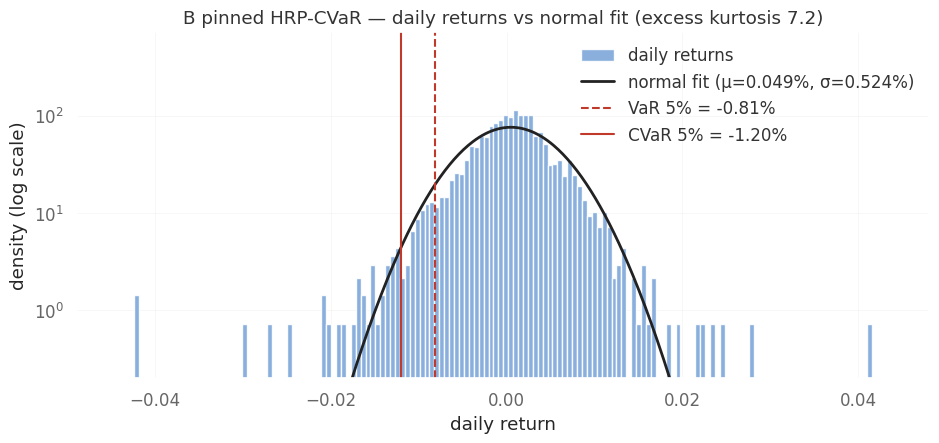

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sps

ALPHA = 0.05


def tail_row(r):
    mu, sd = r.mean(), r.std()
    var = r.quantile(ALPHA)
    cvar = r[r <= var].mean()
    z = sps.norm.ppf(ALPHA)
    cvar_norm = mu - sd * sps.norm.pdf(z) / ALPHA  # CVaR if returns were N(mu, sd)
    return {
        "skew":            sps.skew(r),
        "excess_kurtosis": sps.kurtosis(r),          # 0 for a normal
        "VaR_5%":          var,
        "CVaR_5%":         cvar,
        "CVaR_5%_normal":  cvar_norm,
        "CVaR_ratio":      cvar / cvar_norm,         # >1 -> fatter left tail than normal
        "jarque_bera_p":   sps.jarque_bera(r).pvalue,
    }


rets = {name: pf.returns().loc[SIM_START:].dropna() for name, pf in pfs.items()}
tails = pd.DataFrame({name: tail_row(r) for name, r in rets.items()}).round(4)
display(tails)

FOCUS = "B pinned HRP-CVaR"
r = rets[FOCUS]
mu, sd = r.mean(), r.std()
var5, cvar5 = tails.loc["VaR_5%", FOCUS], tails.loc["CVaR_5%", FOCUS]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(r, bins=150, density=True, color="#7da7d9", alpha=0.9, label="daily returns")
x = np.linspace(r.min() * 1.05, r.max() * 1.05, 500)
ax.plot(x, sps.norm.pdf(x, mu, sd), color="#222222", lw=2,
        label=f"normal fit (μ={mu:.3%}, σ={sd:.3%})")
ax.axvline(var5, color="#c0392b", ls="--", lw=1.5, label=f"VaR 5% = {var5:.2%}")
ax.axvline(cvar5, color="#c0392b", ls="-", lw=1.5, label=f"CVaR 5% = {cvar5:.2%}")
ax.set_yscale("log")
ax.set_ylim(bottom=0.2)
ax.set_xlabel("daily return")
ax.set_ylabel("density (log scale)")
ax.set_title(f"{FOCUS} — daily returns vs normal fit "
             f"(excess kurtosis {tails.loc['excess_kurtosis', FOCUS]:.1f})")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False);

## 7. Notes

- **Pure HRP-CVaR** degenerates to ~97% cash because BIL's CVaR is ~0. That's the "correct" HRP-CVaR output given the inputs; it just isn't the allocation the user intended. Reported for completeness.
- **Pinned HRP-CVaR** keeps the 25% cash sleeve and lets HRP-CVaR re-balance the 3 risky ETFs annually — this is the operationally meaningful baseline.
- **Pinned HRP + BL tilt** adds one view (world equity outperforms cash by 5%/yr) and blends 30% toward the BL posterior. With only one directional view the marginal impact is small; tilts stack up if you add more views.
- **Still in-sample** on the SSR selection. A clean walk-forward would re-score the universe each year and let the category picks rotate.